# Assignment 1: Housing Price Prediction

**Goal:** Predict `SalePrice` for houses in the Ames Housing dataset using a complete machine-learning workflow:

**Explore data → Split data → Preprocess → Select/engineer features → Train models → Evaluate and interpret**

The focus is not the highest possible score, but understanding the data and being able to **explain and justify** your decisions. Write short explanations in the markdown cells along the way (replace the text marked *✏️ Your answer*).

> Use only `AmesHousing.csv`, and the *Ames Housing – Understanding the Dataset* guide whenever a column name or code is unclear.

## 0. Setup

Import the libraries you need. This cell is already filled in – add more imports if needed.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE = 42          # used everywhere for reproducible results
pd.set_option("display.max_columns", 100)

### Load the dataset

In [42]:
df = pd.read_csv("AmesHousing.csv")
print(df.shape)
df.head()

(2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


---
## Step 1 – Explore and understand the data

Explore the dataset using descriptive statistics and visualizations. Choose analyses that actually help you make later decisions – do not create plots just for the sake of it.

The assignment asks you to investigate:
1. the available variables and their data types
2. the distribution of `SalePrice`
3. missing values
4. unusual values or patterns
5. relationships that may be useful for predicting house prices

### 1.1 Variables and data types

In [27]:
# HINT: Use df.info() and df.dtypes to inspect the data types.
# Split the columns into numerical and categorical, e.g.:
#   num_cols = df.select_dtypes(include="number").columns
#   cat_cols = df.select_dtypes(exclude="number").columns
# Note: some "numerical" columns are actually categorical (e.g. 'MS SubClass'),
# and 'Order' / 'PID' are just IDs. Check the dataset guide!
df.info()
df.dtypes


<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

Order               int64
PID                 int64
MS SubClass         int64
MS Zoning             str
Lot Frontage      float64
                   ...   
Mo Sold             int64
Yr Sold             int64
Sale Type             str
Sale Condition        str
SalePrice           int64
Length: 82, dtype: object

In [28]:
num_cols = df.select_dtypes(include="number").columns
print(num_cols)
cat_cols = df.select_dtypes(exclude="number").columns
print(cat_cols)

Index(['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area',
       'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add',
       'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
       'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd',
       'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area',
       'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch',
       'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold',
       'SalePrice'],
      dtype='str')
Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'B

*✏️ Your answer: What kinds of variables do we have? Are there columns with the wrong type or that are not useful?*

### 1.2 Distribution of `SalePrice`

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64
Skewness: 1.7435000757376466


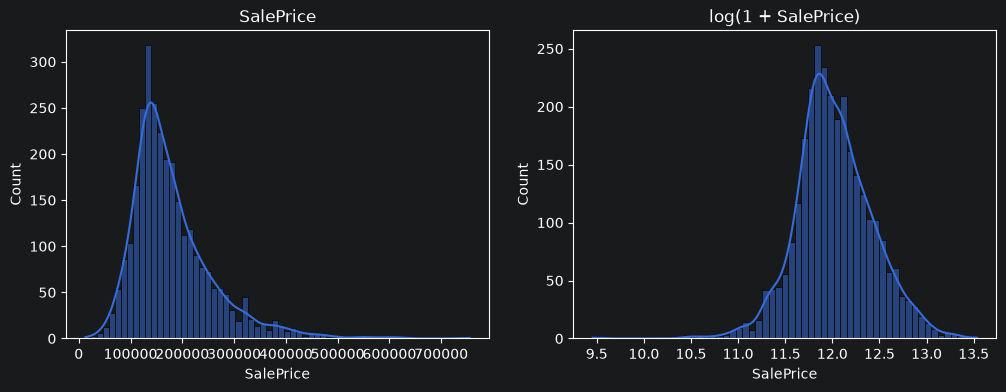

In [43]:
print(df["SalePrice"].describe())
print("Skewness:", df["SalePrice"].skew())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title("SalePrice")
sns.histplot(np.log1p(df["SalePrice"]), kde=True, ax=axes[1])
axes[1].set_title("log(1 + SalePrice)")
plt.show()

*✏️ Your answer: What does the distribution look like? Is it skewed? Could a log transformation be useful?*

### 1.3 Missing values

In [45]:
missing_count = df.isnull().sum()                 # antall NaN per kolonne
missing_pct = missing_count / len(df) * 100       # andel i prosent

missing = pd.DataFrame({
    "Missing": missing_count,
    "Percent": missing_pct.round(2)
})

missing = missing[missing["Missing"] > 0].sort_values("Missing", ascending=False)
print(f"{len(missing)} columns have missing values")
missing

27 columns have missing values


,Missing,Percent
Pool QC,2917,99.56
Misc Feature,2824,96.38
Alley,2732,93.24
Fence,2358,80.48
Mas Vnr Type,1775,60.58
Fireplace Qu,1422,48.53
Lot Frontage,490,16.72
Garage Qual,159,5.43
Garage Cond,159,5.43
Garage Yr Blt,159,5.43


*✏️ Your answer: Which columns have many missing values? Does "missing" actually mean "does not exist"?*
*(E.g. `Pool QC` = NA usually means "no pool" according to the guide – that is information, not an error.)*

### 1.4 Unusual values and patterns

In [31]:
# HINT: Look for outliers, e.g. a scatter plot of 'Gr Liv Area' vs 'SalePrice'.
# (The dataset documentation mentions a few very large houses with low prices.)
# Also check df.describe() for strange min/max values, and categories with very few observations
# (df[col].value_counts()).

*✏️ Your answer: Which unusual observations did you find, and what will you do with them?*

### 1.5 Relationships with `SalePrice`

In [32]:
# HINT: Numerical variables: compute the correlation with SalePrice
#   df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
# Consider a heatmap (sns.heatmap) of the ~10 most correlated variables.
# Categorical variables: use box plots, e.g. sns.boxplot(x="Overall Qual", y="SalePrice", data=df)
# or 'Neighborhood' vs SalePrice.

*✏️ Your answer: Which variables seem most related to the price? Are some of them strongly correlated with each other (multicollinearity)? (→ Q1, Q2)*

---
## Step 2 – Create training and test data

Split the dataset into a training set and a test set. **All** further development (preprocessing, feature selection) must be done on the training data. The test set is only used at the very end.

In [33]:
# HINT: Separate the target from the features:
#   X = df.drop(columns=["SalePrice"])
#   y = df["SalePrice"]
# Use train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE).
# Print the sizes of X_train and X_test.
# Think: should outliers be removed before or after the split? (Only from the training data!)

*✏️ Your answer: How did you split the data, and why must the test set be kept separate? (→ Q3)*

---
## Step 3 – Prepare the data

Decide how to prepare the data for the models. **Important:** preprocessing must be *learned* (fit) on the training data and then *applied* (transform) in the same way to the test data.

Possible steps:
- handle missing values (based on what they mean in the guide)
- encode categorical variables
- scale/transform numerical variables where appropriate
- remove variables when there is a clear reason to do so

### 3.1 Remove irrelevant columns

In [34]:
# HINT: Drop ID columns such as 'Order' and 'PID' from X_train and X_test – they say nothing about the price.
# Also consider columns that are almost entirely missing or have almost only one value.

### 3.2 Missing values that mean "does not exist"

In [35]:
# HINT: For columns where NA means "none" (e.g. 'Alley', 'Pool QC', 'Fence', 'Garage Type',
# 'Bsmt Qual', 'Fireplace Qu', ...), fill in a separate category such as "None".
# For the related numerical columns (e.g. 'Garage Area', 'Total Bsmt SF') 0 often makes sense.
# Consider writing a function for this and applying it to both X_train and X_test
# (this is rule-based, not "learned", so it is safe to apply to both).

### 3.3 Preprocessing pipeline (imputation, encoding, scaling)

In [36]:
# HINT: Remaining missing values are filled with values LEARNED from the training data:
#   - numerical: SimpleImputer(strategy="median")
#   - categorical: SimpleImputer(strategy="most_frequent")
# Categorical variables: OneHotEncoder(handle_unknown="ignore")
# Numerical: StandardScaler() (matters most for LinearRegression, the tree models don't care).
#
# Combine them with a ColumnTransformer, e.g.:
#   num_pipe = Pipeline([("imputer", ...), ("scaler", ...)])
#   cat_pipe = Pipeline([("imputer", ...), ("onehot", ...)])
#   preprocessor = ColumnTransformer([("num", num_pipe, num_features),
#                                     ("cat", cat_pipe, cat_features)])
# Remember: the preprocessor must only be fit on X_train (this happens automatically if it is part of a Pipeline in Step 5).

*✏️ Your answer: Explain your choices for missing values, categorical variables and scaling. Why is this learned only from the training data? (→ Q4)*

---
## Step 4 – Select and engineer features

Decide which features to use. Use evidence from the **training data** (correlations, plots, understanding of the variables). You do not have to use every column.

*Tip: Steps 3 and 4 are connected – it may be easiest to do the feature engineering (4.1) before building the pipeline in 3.3, since the pipeline needs the final `num_features` and `cat_features` lists.*

### 4.1 Feature engineering

In [37]:
# HINT: Create new, meaningful features on both X_train and X_test, e.g.:
#   - 'Total SF'   = 'Total Bsmt SF' + '1st Flr SF' + '2nd Flr SF'
#   - 'House Age'  = 'Yr Sold' - 'Year Built'
#   - 'Remod Age'  = 'Yr Sold' - 'Year Remod/Add'
#   - 'Total Bath' = 'Full Bath' + 0.5*'Half Bath' + 'Bsmt Full Bath' + 0.5*'Bsmt Half Bath'
# Check the correlation of the new features with y_train.

### 4.2 Feature selection

In [38]:
# HINT: Compute correlations with y_train (use the training data only!).
# E.g. choose numerical features with |correlation| above a threshold + some important categorical ones
# (e.g. 'Neighborhood', 'Kitchen Qual', 'Exter Qual').
# Consider dropping one of two nearly identical features (e.g. 'Garage Cars' vs 'Garage Area').
# Store the final lists in num_features and cat_features.

*✏️ Your answer: Which features did you finally use? What did you remove/create, and why? (→ Q2, Q5)*

---
## Step 5 – Train the models

Train the three models **using the same prepared features**, so that they can be compared fairly. Use the default hyperparameters (no tuning required).

- `LinearRegression`
- `DecisionTreeRegressor`
- `RandomForestRegressor`

In [39]:
# HINT: Create a dictionary with the models:
#   models = {
#       "Linear Regression": LinearRegression(),
#       "Decision Tree Regression": DecisionTreeRegressor(random_state=RANDOM_STATE),
#       "Random Forest Regression": RandomForestRegressor(random_state=RANDOM_STATE),
#   }
# Loop over them, build a Pipeline([("prep", preprocessor), ("model", model)]) for each,
# and call .fit(X_train, y_train). Store the trained pipelines in a new dictionary.

---
## Step 6 – Evaluate and interpret the results

Evaluate all three models on the **test data** using:
- **RMSE** – the size of the prediction errors in the same units as `SalePrice` (lower is better)
- **R²** – compares the predictions with a baseline that always predicts the mean (higher is generally better; 1 = perfect, 0 = no better than the mean, can be negative). *Do not describe R² as percentage accuracy.*

| Model | Test RMSE | Test R² |
|---|---|---|
| Linear Regression | | |
| Decision Tree Regression | | |
| Random Forest Regression | | |

In [40]:
# HINT: For each trained model:
#   y_pred = model.predict(X_test)
#   rmse = np.sqrt(mean_squared_error(y_test, y_pred))
#   r2   = r2_score(y_test, y_pred)
# Collect the results in a pd.DataFrame with the columns "Model", "Test RMSE", "Test R²".
# If you log-transformed y: remember to transform the predictions back (np.expm1) before computing RMSE!

### 6.1 Visualizing the predictions

In [41]:
# HINT: Scatter plot of y_test (x-axis) vs y_pred (y-axis) for each model,
# with a diagonal line y = x for perfect predictions. Consider plt.subplots(1, 3).
# Look for where the models make the largest errors (expensive houses? cheap houses?).

*✏️ Your answer: Which model performed best on the test data? Why do you think so? (→ Q6)*

---
## Summary and possible improvements

*✏️ Your answer: What could you change in the preprocessing or features to improve the results without changing to a different model? (→ Q7)*